In [1]:
import pandas as pd
sub = pd.read_csv("/kaggle/input/cafa-6-protein-function-prediction/sample_submission.tsv", sep= "\t", header = None,on_bad_lines="skip")
sub.columns = ["The Protein ID", "The Gene Ontology term (GO) ID", "Predicted link probability that GO appear in Protein"]
sub.head(5)

,The Protein ID,The Gene Ontology term (GO) ID,Predicted link probability that GO appear in Protein
0,A0A0C5B5G6,GO:0000001,0.123
1,A0A0C5B5G6,GO:0000002,0.456
2,A0A1B0GTW7,GO:0000001,0.123
3,A0A1B0GTW7,GO:0000002,0.456
4,A0JNW5,GO:0000001,0.123


In [2]:
MAIN_DIR = "/kaggle/input/cafa-6-protein-function-prediction"

import wandb
import os
import numpy as np
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import torch
from torch.utils.data import Dataset
from torch import nn
from torch.utils.data import random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics.classification import MultilabelF1Score
from torchmetrics.classification import MultilabelAccuracy

import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import WandbLogger

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
class config:
    train_sequences_path = MAIN_DIR  + "/Train/train_sequences.fasta"
    train_labels_path = MAIN_DIR + "/Train/train_terms.tsv"
    test_sequences_path = MAIN_DIR + "/Test (Targets)/testsuperset.fasta"
    
    num_labels = 500
    n_epochs = 5
    batch_size = 50
    lr = 0.01
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

embeds_map = {
    "T5" : "t5embeds",
    "ProtBERT" : "cafa6-protbert-embeddings",
    "EMS2" : "cafa-6-ems-2-embeddings-numpy"
}

embeds_dim = {
    "T5" : 1024,
    "ProtBERT" : 1024,
    "EMS2" : 1280
}

In [4]:
class ProteinSequenceDataset(Dataset):
    
    def __init__(self, datatype, embeddings_source):
        super(ProteinSequenceDataset).__init__()
        self.datatype = datatype
        
        if embeddings_source in ["ProtBERT", "EMS2"]:
            embeds = np.load("/kaggle/input/"+embeds_map[embeddings_source]+"/"+datatype+"_embeddings.npy")
            ids = np.load("/kaggle/input/"+embeds_map[embeddings_source]+"/"+datatype+"_ids.npy")
        
        if embeddings_source == "T5":
            embeds = np.load("/kaggle/input/"+embeds_map[embeddings_source]+"/"+datatype+"_embeds.npy")
            ids = np.load("/kaggle/input/"+embeds_map[embeddings_source]+"/"+datatype+"_ids.npy")
            
        embeds_list = []
        for l in range(embeds.shape[0]):
            embeds_list.append(embeds[l,:])
        self.df = pd.DataFrame(data={"EntryID": ids, "embed" : embeds_list})
        
        if datatype=="train":
            np_labels = np.load(
                "/kaggle/input/cafa6top500"+ \
                "/train_targets_top"+str(config.num_labels)+".npy")
            df_labels = pd.DataFrame(self.df['EntryID'])
            df_labels['labels_vect']=[row for row in np_labels]
            self.df = self.df.merge(df_labels, on="EntryID")
            
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        embed = torch.tensor(self.df.iloc[index]["embed"] , dtype = torch.float32)
        if self.datatype=="train":
            targets = torch.tensor(self.df.iloc[index]["labels_vect"], dtype = torch.float32)
            return embed, targets
        if self.datatype=="test":
            id = self.df.iloc[index]["EntryID"]
            return embed, id
        

In [5]:
class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self, input_dim, num_classes, num_heads=8, bottleneck_dim=256):
        super(MultiLayerPerceptron, self).__init__()
        
        self.linear1 = torch.nn.Linear(input_dim, 864)
        self.bn1 = torch.nn.BatchNorm1d(864, track_running_stats=True)
        self.activation1 = torch.nn.ReLU()
        self.dropout1 = torch.nn.Dropout(0.3)
        
        self.bottleneck = torch.nn.Linear(864, bottleneck_dim)
        self.bn_bottleneck = torch.nn.BatchNorm1d(bottleneck_dim, track_running_stats=True)
        self.activation_bottleneck = torch.nn.ReLU()
        
        self.num_heads = num_heads
        self.attention = torch.nn.MultiheadAttention(
            embed_dim=bottleneck_dim,
            num_heads=num_heads,
            dropout=0.1,
            batch_first=True
        )
        self.layer_norm1 = torch.nn.LayerNorm(bottleneck_dim)
        
        self.expand = torch.nn.Linear(bottleneck_dim, 712)
        self.bn2 = torch.nn.BatchNorm1d(712, track_running_stats=True)
        self.activation2 = torch.nn.ReLU()
        self.dropout2 = torch.nn.Dropout(0.3)
        
        self.linear3 = torch.nn.Linear(712, num_classes)
      
    def forward(self, x):
        batch_size = x.size(0)
        
        x = self.linear1(x)
        if batch_size > 1 or not self.training:
            x = self.bn1(x)
        x = self.activation1(x)
        x = self.dropout1(x)
        
        x = self.bottleneck(x)
        if batch_size > 1 or not self.training:
            x = self.bn_bottleneck(x)
        x = self.activation_bottleneck(x)
        
        x_attention = x.unsqueeze(1) 
        
        attn_output, _ = self.attention(x_attention, x_attention, x_attention)
        x_attention = self.layer_norm1(x_attention + attn_output)
        
        x = x_attention.squeeze(1)
        
        x = self.expand(x)
        if batch_size > 1 or not self.training:
            x = self.bn2(x)
        x = self.activation2(x)
        x = self.dropout2(x)
        
        x = self.linear3(x)
        return x

In [6]:
def train_model(embeddings_source, model_type="linear", train_size=0.9):
    
    train_dataset = ProteinSequenceDataset(datatype="train", embeddings_source=embeddings_source)
    
    train_set, val_set = random_split(
        train_dataset, 
        lengths=[int(len(train_dataset)*train_size), 
                len(train_dataset)-int(len(train_dataset)*train_size)],
        generator=torch.Generator().manual_seed(42)  
    )
    
    train_dataloader = torch.utils.data.DataLoader(
        train_set, batch_size=config.batch_size, shuffle=True, 
        num_workers=4, pin_memory=True  
    )
    val_dataloader = torch.utils.data.DataLoader(
        val_set, batch_size=config.batch_size, shuffle=False, 
        num_workers=4, pin_memory=True
    )
    
    if model_type == "linear":
        model = nn.DataParallel(MultiLayerPerceptron(input_dim=embeds_dim[embeddings_source], 
                                                     num_classes=config.num_labels,
                                                     num_heads=8,  # adjustable
                                                     bottleneck_dim=256  # adjustable
                                                    )).to(config.device)
    else:
        raise ValueError(f"Unknown model_type: {model_type}. Choose 'linear' or 'convolutional'")
        
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=2, verbose=True)
    criterion = torch.nn.CrossEntropyLoss()
    f1_score = MultilabelF1Score(num_labels=config.num_labels).to(config.device)
    
    n_epochs = config.n_epochs
    print("BEGIN TRAINING...")
    
    train_loss_history = []
    val_loss_history = []
    train_f1score_history = []
    val_f1score_history = []
    
    best_val_score = 0.0
    best_model_state = None
    patience_counter = 0
    early_stopping_patience = 5
    
    for epoch in range(n_epochs):
        print(f"EPOCH {epoch+1}/{n_epochs}")
        
        ## TRAIN PHASE
        model.train()
        train_losses = []
        train_scores = []
        
        for embed, targets in tqdm(train_dataloader, desc="Training"):
            embed = embed.to(config.device, non_blocking=True)
            targets = targets.to(config.device, non_blocking=True)
            
            optimizer.zero_grad()
            preds = model(embed)
            loss = criterion(preds, targets)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
            optimizer.step()
            
            train_losses.append(loss.item())
            
            with torch.no_grad():
                score = f1_score(preds, targets)
                train_scores.append(score.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_train_score = np.mean(train_scores)
        print(f"Train Loss: {avg_train_loss:.4f} | Train F1-Score: {avg_train_score:.4f}")
        train_loss_history.append(avg_train_loss)
        train_f1score_history.append(avg_train_score)
        
        ## VALIDATION PHASE
        model.eval()
        val_losses = []
        val_scores = []
        
        with torch.no_grad(): 
            for embed, targets in tqdm(val_dataloader, desc="Validation"):
                embed = embed.to(config.device, non_blocking=True)
                targets = targets.to(config.device, non_blocking=True)
                
                preds = model(embed)
                loss = criterion(preds, targets)
                score = f1_score(preds, targets)
                
                val_losses.append(loss.item())
                val_scores.append(score.item())
        
        avg_val_loss = np.mean(val_losses)
        avg_val_score = np.mean(val_scores)
        print(f"Val Loss: {avg_val_loss:.4f} | Val F1-Score: {avg_val_score:.4f}")
        val_loss_history.append(avg_val_loss)
        val_f1score_history.append(avg_val_score)
        
        if avg_val_score > best_val_score:
            best_val_score = avg_val_score
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"✓ New best model saved (F1: {best_val_score:.4f})")
        else:
            patience_counter += 1
        
        scheduler.step(avg_val_loss)
        
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
        
        print()
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Restored best model with validation F1-Score: {best_val_score:.4f}")
    
    print("TRAINING FINISHED")
    print(f"Final Training F1-Score: {train_f1score_history[-1]:.4f}")
    print(f"Best Validation F1-Score: {best_val_score:.4f}")
    
    history = {
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "train_f1": train_f1score_history,
        "val_f1": val_f1score_history
    }
    
    return model, val_loss_history, val_f1score_history

In [7]:
protbert_model, protbert_losses, protbert_scores = train_model(embeddings_source = "ProtBERT",
                                                               model_type = "linear")

BEGIN TRAINING...
EPOCH 1/5


Training:   0%|          | 1/1484 [00:01<39:44,  1.61s/it]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return F.linear(input, self.weight, self.bias)
Training: 100%|██████████| 1484/1484 [00:22<00:00, 66.59it/s]


Train Loss: 16.6020 | Train F1-Score: 0.0060


Validation: 100%|██████████| 165/165 [00:01<00:00, 104.39it/s]


Val Loss: 16.2761 | Val F1-Score: 0.0065
✓ New best model saved (F1: 0.0065)

EPOCH 2/5


...

Val Loss: 16.2600 | Val F1-Score: 0.0073
✓ New best model saved (F1: 0.0073)

EPOCH 5/5


Training: 100%|██████████| 1484/1484 [00:21<00:00, 70.66it/s]


Train Loss: 16.3298 | Train F1-Score: 0.0073


Validation: 100%|██████████| 165/165 [00:01<00:00, 104.65it/s]

Val Loss: 16.2633 | Val F1-Score: 0.0073
✓ New best model saved (F1: 0.0073)

Restored best model with validation F1-Score: 0.0073
TRAINING FINISHED
Final Training F1-Score: 0.0073
Best Validation F1-Score: 0.0073


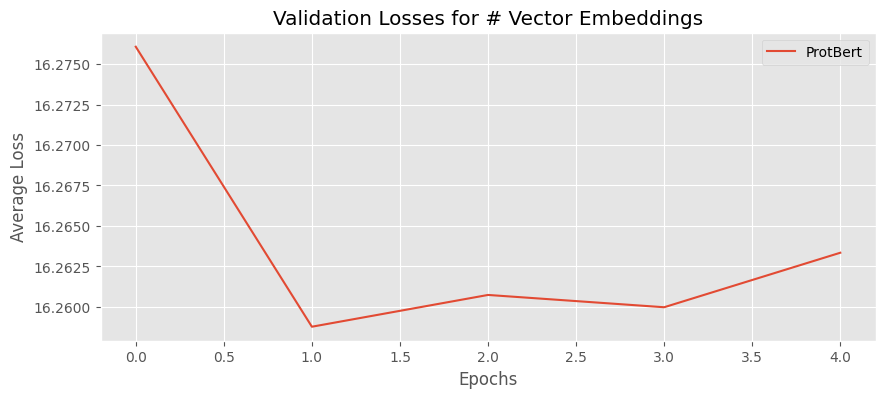

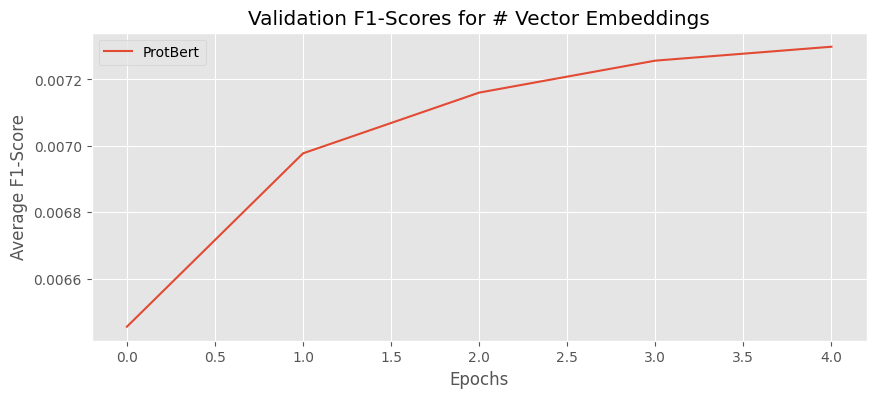

In [8]:
plt.figure(figsize = (10, 4))
plt.plot(protbert_losses, label = "ProtBert") 
plt.title("Validation Losses for # Vector Embeddings")
plt.xlabel("Epochs")
plt.ylabel("Average Loss")
plt.legend()
plt.show()

plt.figure(figsize = (10, 4))
plt.plot(protbert_scores, label = "ProtBert")
plt.title("Validation F1-Scores for # Vector Embeddings")
plt.xlabel("Epochs")
plt.ylabel("Average F1-Score")
plt.legend()
plt.show()

## PREDICTION

In [9]:
def predict(embeddings_source):
    
    test_dataset = ProteinSequenceDataset(datatype="test", embeddings_source = embeddings_source)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    if embeddings_source == "T5":
        model = t5_model
    if embeddings_source == "ProtBERT":
        model = protbert_model
    if embeddings_source == "EMS2":
        model = ems2_model
        
    model.eval()
    
    labels = pd.read_csv(config.train_labels_path, sep = "\t")
    top_terms = labels.groupby("term")["EntryID"].count().sort_values(ascending=False)
    labels_names = top_terms[:config.num_labels].index.values
    print("GENERATE PREDICTION FOR TEST SET...")

    ids_ = np.empty(shape=(len(test_dataloader)*config.num_labels,), dtype=object)
    go_terms_ = np.empty(shape=(len(test_dataloader)*config.num_labels,), dtype=object)
    confs_ = np.empty(shape=(len(test_dataloader)*config.num_labels,), dtype=np.float32)

    for i, (embed, id) in tqdm(enumerate(test_dataloader)):
        embed = embed.to(config.device)
        confs_[i*config.num_labels:(i+1)*config.num_labels] = torch.nn.functional.sigmoid(model(embed)).squeeze().detach().cpu().numpy()
        ids_[i*config.num_labels:(i+1)*config.num_labels] = id[0]
        go_terms_[i*config.num_labels:(i+1)*config.num_labels] = labels_names

    submission_df = pd.DataFrame(data={"Id" : ids_, "GO term" : go_terms_, "Confidence" : confs_})
    print("PREDICTIONS DONE")
    return submission_df

In [10]:
submission_df = predict("ProtBERT")

GENERATE PREDICTION FOR TEST SET...


224309it [10:33, 354.08it/s]


PREDICTIONS DONE


In [11]:
len(submission_df)

112154500

In [12]:
submission_df.to_csv('submission.tsv', sep='\t', header=False, index=False)